# Practical Statistics for Data Scientists (Python)
# Chapter 2. Data and Sampling Distributions
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import required Python packages.

In [3]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [5]:
%%R
library(boot)
library(ggplot2)

## Defining data paths
If you don't keep your data in the same directory as the code, adapt the path names.

### Data Assignment - Python

In [6]:
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'

### Data Assignment - R

In [7]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))

loans_income <- read.csv(file.path(PSDS_PATH, 'data', 'loans_income.csv'))
loans_income <- loans_income[, 1]   # convert data frame to vector
sp500_px <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_data.csv.gz'), row.names=1)

### Python - Figure 2.1

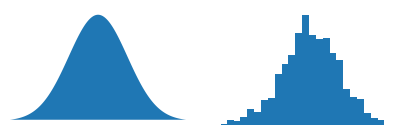

In [8]:
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

### R - Figure 2.1

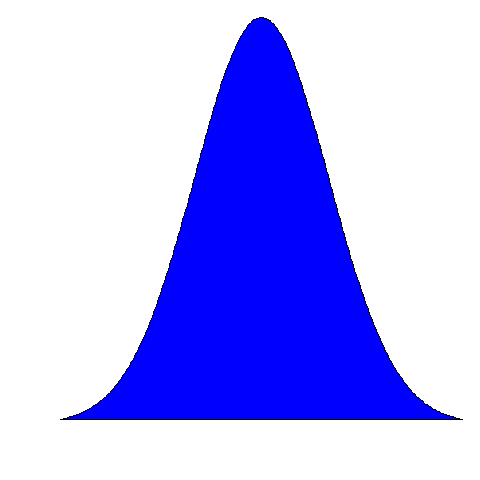

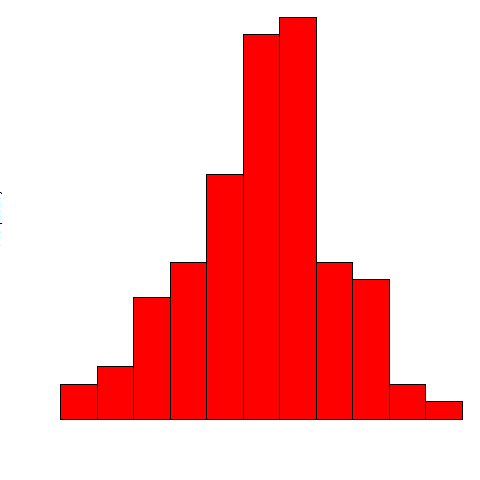

In [9]:
%%R
x <- seq(from=-3, to=3, length=300)
gauss <- dnorm(x)

par(mar=c(3, 3, 0, 0)+.1)
plot(x, gauss, type='l', col='blue', xlab='', ylab='', axes=FALSE)
polygon(x, gauss, col='blue')

norm_samp <- rnorm(100)
par(mar=c(3, 3, 0, 0)+.1)
hist(norm_samp, axes=FALSE, col='red', main='')

# Sampling Distribution of a Statistic

### Python

In [10]:
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')

sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

         income  type
40292   63000.0  Data
38959   92000.0  Data
17361  134000.0  Data
33996   52000.0  Data
26491   43000.0  Data


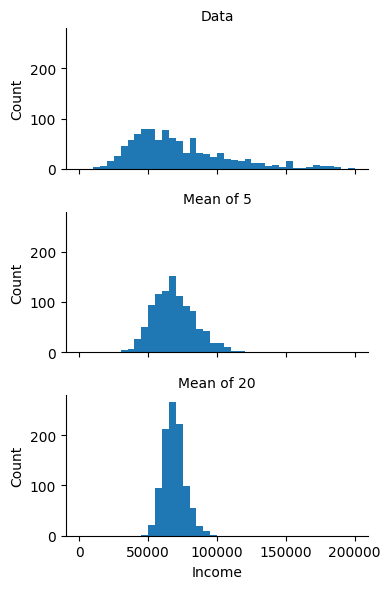

In [11]:
g = sns.FacetGrid(results, col='type', col_wrap=1, 
                  height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

### R

In [12]:
%%R
# take a simple random sample
samp_data <- data.frame(income=sample(loans_income, 1000), 
                        type='data_dist')

# take a sample of means of 5 values
samp_mean_05 <- data.frame(
  income = tapply(sample(loans_income, 1000*5), 
                  rep(1:1000, rep(5, 1000)), FUN=mean),
  type = 'mean_of_5')

# take a sample of means of 20 values
samp_mean_20 <- data.frame(
  income = tapply(sample(loans_income, 1000*20), 
                  rep(1:1000, rep(20, 1000)), FUN=mean),
  type = 'mean_of_20')

# bind the data.frames and convert type to a factor
income <- rbind(samp_data, samp_mean_05, samp_mean_20)
income$type <- factor(income$type, 
                     levels=c('data_dist', 'mean_of_5', 'mean_of_20'),
                     labels=c('Data', 'Mean of 5', 'Mean of 20'))

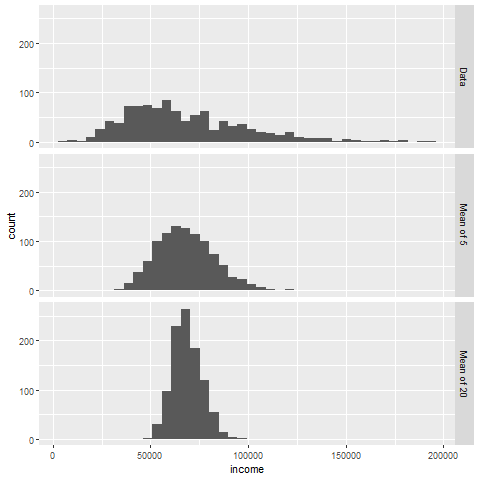

In [13]:
%%R
ggplot(income, aes(x=income)) +
  geom_histogram(bins=40) +
  facet_grid(type ~ .)

# The Bootstrap
As the calculation uses random samples, results will vary between runs

### Python

In [14]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -82.09799999999814
std. error: 228.73933106830927


### R

In [15]:
%%R
stat_fun <- function(x, idx) median(x[idx])
boot_obj <- boot(loans_income, R=1000, statistic=stat_fun)

boot_obj


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = loans_income, statistic = stat_fun, R = 1000)


Bootstrap Statistics :
    original  bias    std. error
    62000 -77.053    213.9904


# Confidence Intervals

### Python

68760.51844
55734.1


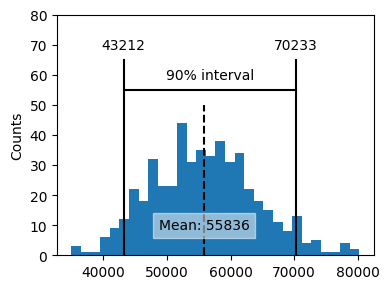

In [16]:
print(loans_income.mean())
np.random.seed(seed=3)  
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Counts')

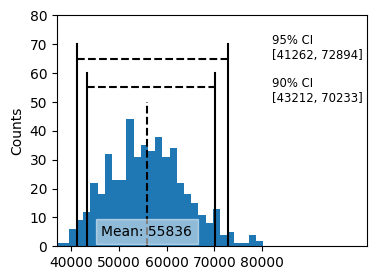

In [17]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color='C1')
ax.plot(confidence_interval, [55, 55], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color='black')
ax.text(82000, 50, 
        f'90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color='black')
ax.text(82000, 65, 
        f'95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')
# ax.text(sum(confidence_interval) / 2, 264, '95 % interval',
#         horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 5, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel('Counts')

# plt.tight_layout()
# plt.show()

### R

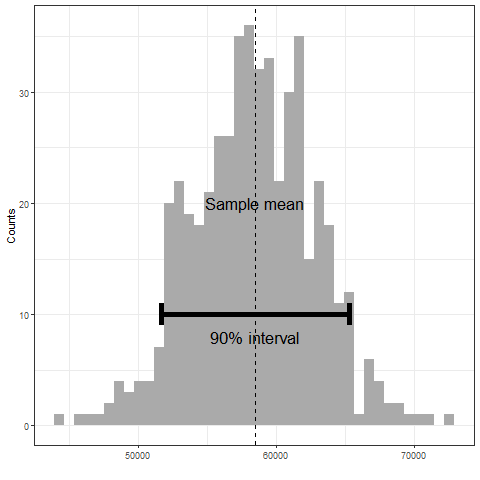

In [18]:
%%R
# R version for figure 2-9 not available
set.seed(5)
set.seed(7)
sample20 <- sample(loans_income, 20)
sampleMean <- mean(sample20)

stat_fun <- function(x, idx) mean(x[idx])
boot_obj <- boot(sample20, R=500, statistic=stat_fun)
boot_ci <- boot.ci(boot_obj, conf=0.9, type='basic')
X <- data.frame(mean=boot_obj$t)
ci90 <- boot_ci$basic[4:5]
ci <- data.frame(ci=ci90, y=c(9, 11))
ci
ggplot(X, aes(x=mean)) +
    geom_histogram(bins=40, fill='#AAAAAA') +
    geom_vline(xintercept=sampleMean, linetype=2) +
    geom_path(aes(x=ci, y=10), data=ci, linewidth=2) +
    geom_path(aes(x=ci90[1], y=y), data=ci, linewidth=2) +
    geom_path(aes(x=ci90[2], y=y), data=ci, linewidth=2) +
    annotate('text', x=sampleMean, y=20, label='Sample mean', size=6) +
    annotate('text', x=sampleMean, y=8, label='90% interval', size=6) +
    theme_bw() + 
    labs(x='', y='Counts')

# Normal Distribution
## Standard Normal and QQ-Plots

### Python
The package _scipy_ has the function (`scipy.stats.probplot`) to create QQ-plots. The argument `dist` specifies the distribution, which is set by default to the normal distribution.

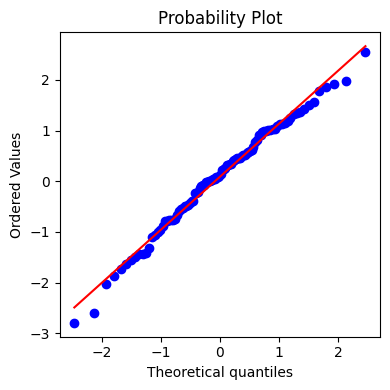

In [19]:
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)

plt.tight_layout()
plt.show()

### R

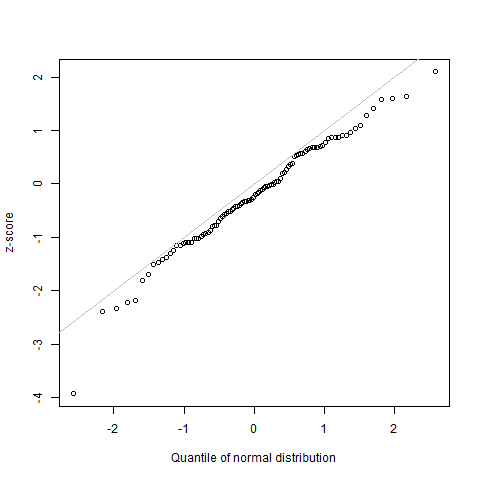

In [20]:
%%R
norm_samp <- rnorm(100)
qqnorm(norm_samp, main='', xlab='Quantile of normal distribution', ylab='z-score')
abline(a=0, b=1, col='grey')

# Long-Tailed Distributions

### Python

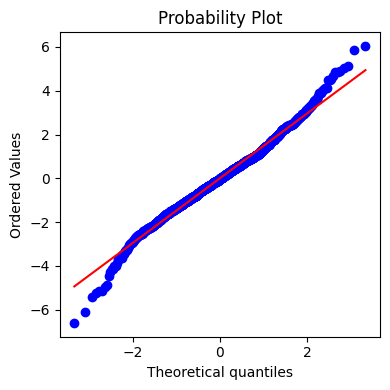

In [21]:
sp500_px = pd.read_csv(SP500_DATA_CSV)

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx>0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)

plt.tight_layout()
plt.show()

### R

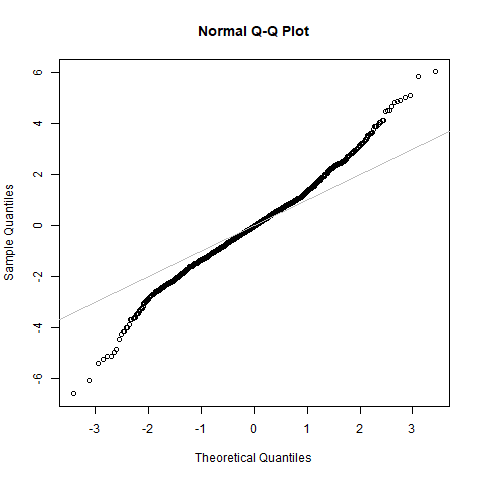

In [22]:
%%R
nflx <- sp500_px[,'NFLX']
nflx <- diff(log(nflx[nflx>0]))
qqnorm(nflx)
abline(a=0, b=1, col='grey')

# Binomial Distribution

### Python

In [23]:
print(stats.binom.pmf(2, n=5, p=0.1))

0.07289999999999992


In [24]:
print(stats.binom.cdf(2, n=5, p=0.1))

0.99144


### R

In [25]:
%%R
dbinom(x=2, size=5, p=0.1)

[1] 0.0729


In [26]:
%%R
pbinom(2, 5, 0.1)

[1] 0.99144


In [27]:
%%R
dbinom(x=0, size=200, p=0.02)

[1] 0.01758795


# Poisson and Related Distribution
## Poisson Distributions

### Python

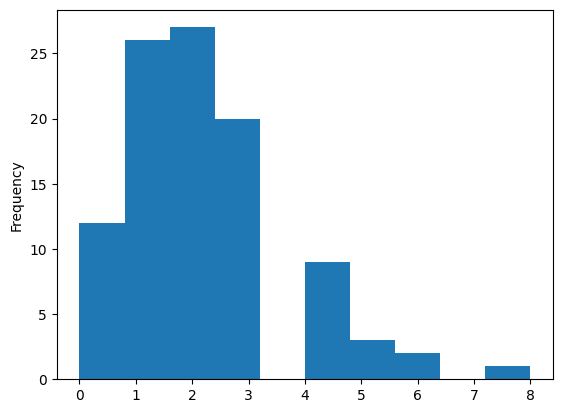

In [28]:
sample = stats.poisson.rvs(2, size=100)

pd.Series(sample).plot.hist()
plt.show()

### R

In [29]:
%%R
rpois(100, lambda=2)

  [1] 1 2 1 3 2 2 2 5 4 1 2 3 2 6 1 5 6 2 3 1 1 1 1 1 3 4 3 0 2 6 5 2 4 1 0 2 0
 [38] 2 3 5 3 1 4 4 4 0 3 3 2 2 0 2 2 4 1 1 3 3 3 4 2 3 3 1 1 2 1 2 3 1 4 0 3 1
 [75] 2 0 3 2 3 0 3 1 2 2 4 0 2 1 2 3 0 1 3 2 2 1 4 0 3 6


## Exponential Distribution

### Python

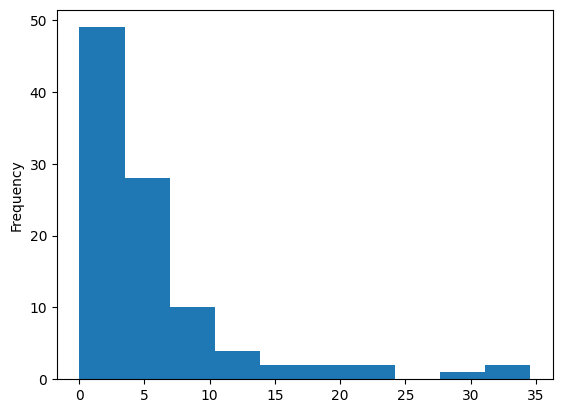

In [30]:
sample = stats.expon.rvs(scale=5, size=100)

pd.Series(sample).plot.hist()
plt.show()

### R

In [31]:
%%R
rexp(n=100, rate=.2)

  [1]  6.638705698  0.006711071 15.878587439  6.385282642  8.689187718
  [6]  0.274932847  1.060285215  6.015904303  0.093875017  6.455080602
 [11]  5.107568993  0.109575669  1.765047924  4.227557843  2.735554227
 [16]  2.997726241 10.191077841  4.240468833  5.387811716  1.497157135
 [21]  7.579095225  5.562681489  0.486764224  6.090781335  6.687533734
 [26] 11.269287234  0.240654313  0.935246479  0.237767026  2.176883069
 [31]  4.110882086  5.987012894  3.275767015  2.445181824  2.651181775
 [36]  6.898406064 19.070931960  4.248119792  0.343186936 12.450818987
 [41]  2.647791156 10.937270921  0.721764060  2.244586736  3.630282255
 [46]  6.024240218  6.942348827  3.908220823  1.472034554  3.390782559
 [51]  2.439800855 37.597482109  4.775333837 11.167763983  8.946549366
 [56]  7.299376037 12.101185163  3.056247963  4.740315424  4.895523689
 [61]  1.628130914 24.576101832 16.337447203  7.101003165 14.902434388
 [66]  3.736279260  8.338185277  7.306550126  9.611410722  5.024689697
 [71] 

##  Weibull Distribution

### Python

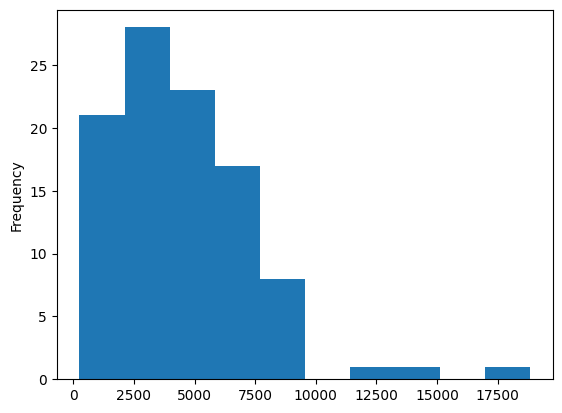

In [32]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

pd.Series(sample).plot.hist()
plt.show()

### R

In [34]:
%%R
rweibull(100, 1.5, 5000)

  [1]  4499.9469  4042.5563  1073.1496  3159.0999  4974.5261  2949.6250
  [7]  2128.0114  2405.7802  1436.2068   990.8704 15948.7863  2193.5512
 [13]   431.2380  8021.5171  7176.8527  1726.1685 15432.2320  3722.5258
 [19]  2315.5834  4688.6165  5773.7101  5957.3862  4420.9181 11118.2133
 [25]  5644.0183   268.1725  3278.2946  5831.1883  1897.1073  2874.1405
 [31]  3694.6321  6936.2837 11993.7819  2089.0115 11197.4556  8322.2591
 [37]  2814.7802   814.7315 10274.4828  2555.7808  3194.2294  5561.8328
 [43]  5051.0215  2202.9072  1804.1324  2940.9301  9353.6981 10680.6408
 [49] 14120.9182  4105.9855  4906.5105  6699.0250  3972.1596  8777.2478
 [55]  4070.6581   402.4620  1870.7039  4313.7891    72.8319  8042.1638
 [61]  2897.0133  4862.7379  6869.3911  6005.3425  3371.3165  3218.0901
 [67]   998.1284   757.3426  2220.9315   275.2842  4895.8063  8644.0165
 [73]   762.5403  3827.4317  1314.1232   874.4762   564.9984  6972.1248
 [79]  4515.3303  4234.6136  7463.3809  1168.3263  2127.9401  39